# Bài tập: Dự đoán giá nhà California Housing bằng Multilayer Perceptron (MLP)

Chúng ta sẽ sử dụng bộ dữ liệu `California Housing` từ `sklearn.datasets` để dự đoán giá nhà trung bình.

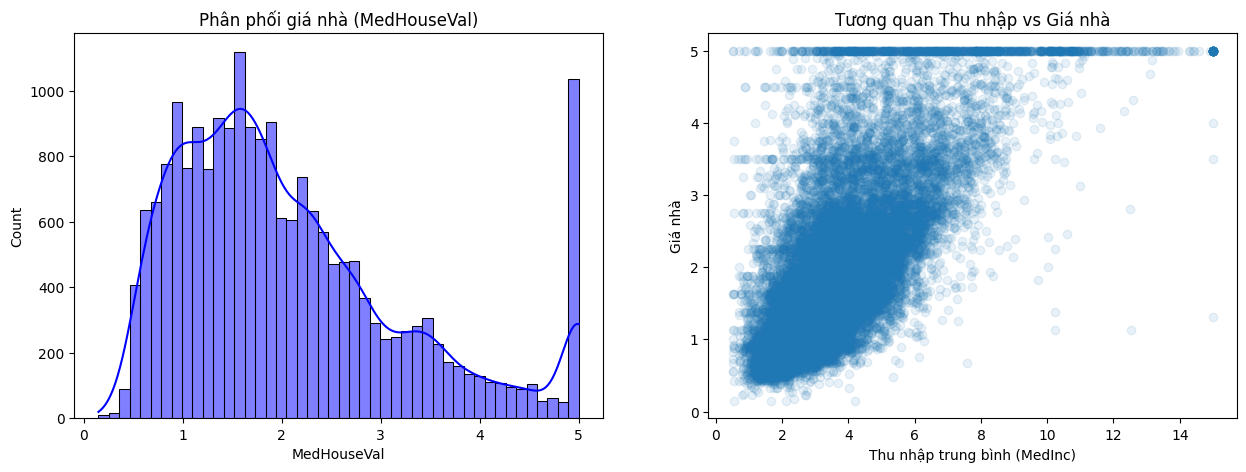

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# 1. Tải và Khám phá dữ liệu
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

# Trực quan hóa dữ liệu (EDA)
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['MedHouseVal'], kde=True, color='blue')
plt.title('Phân phối giá nhà (MedHouseVal)')

plt.subplot(1, 2, 2)
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.1)
plt.xlabel('Thu nhập trung bình (MedInc)')
plt.ylabel('Giá nhà')
plt.title('Tương quan Thu nhập vs Giá nhà')
plt.show()

# Tiền xử lý
X = df.drop('MedHouseVal', axis=1).values
y = df['MedHouseVal'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuẩn hóa (Z-score normalization manually)
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

Based on the output, we can see there are no missing values in the dataset. This means the dataset is already quite clean in terms of missing data, so we don't need to perform any imputation or dropping of rows/columns due to missingness.

In [ ]:
# 2 & 3. Tự triển khai MLP từ đầu (Scratch)
class MLPScratch:
    def __init__(self, layers, lr=0.01):
        self.layers = layers
        self.lr = lr
        self.params = {}
        for i in range(len(layers) - 1):
            self.params[f'W{i+1}'] = np.random.randn(layers[i], layers[i+1]) * 0.1
            self.params[f'b{i+1}'] = np.zeros((1, layers[i+1]))

    def relu(self, Z): return np.maximum(0, Z)
    def relu_derivative(self, Z): return (Z > 0).astype(float)

    def forward(self, X):
        self.A0 = X
        self.Z1 = np.dot(self.A0, self.params['W1']) + self.params['b1']
        self.A1 = self.relu(self.Z1)
        self.Z2 = np.dot(self.A1, self.params['W2']) + self.params['b2']
        self.A2 = self.relu(self.Z2)
        self.Z3 = np.dot(self.A2, self.params['W3']) + self.params['b3']
        return self.Z3

    def train(self, X, y, epochs=100, batch_size=32):
        history = []
        for epoch in range(epochs):
            # Mini-batch gradient descent
            indices = np.random.permutation(X.shape[0])
            for i in range(0, X.shape[0], batch_size):
                idx = indices[i:i+batch_size]
                X_batch, y_batch = X[idx], y[idx]

                # Forward
                pred = self.forward(X_batch)

                # Backward
                dZ3 = pred - y_batch
                dW3 = np.dot(self.A2.T, dZ3) / batch_size
                db3 = np.sum(dZ3, axis=0, keepdims=True) / batch_size

                dZ2 = np.dot(dZ3, self.params['W3'].T) * self.relu_derivative(self.Z2)
                dW2 = np.dot(self.A1.T, dZ2) / batch_size
                db2 = np.sum(dZ2, axis=0, keepdims=True) / batch_size

                dZ1 = np.dot(dZ2, self.params['W2'].T) * self.relu_derivative(self.Z1)
                dW1 = np.dot(self.A0.T, dZ1) / batch_size
                db1 = np.sum(dZ1, axis=0, keepdims=True) / batch_size

                # Update
                for p in ['W1', 'b1', 'W2', 'b2', 'W3', 'b3']:
                    self.params[p] -= self.lr * eval(f'd{p}')

            loss = np.mean((self.forward(X) - y)**2)
            history.append(loss)
            if epoch % 10 == 0: print(f'Epoch {epoch}: Loss {loss:.4f}')
        return history

# Khởi tạo và huấn luyện
mlp = MLPScratch(layers=[8, 64, 32, 1], lr=0.001)
history_scratch = mlp.train(X_train_scaled, y_train, epochs=100)

Epoch 0: Loss 2.2848
Epoch 10: Loss 0.5663
Epoch 20: Loss 0.4870
Epoch 30: Loss 0.4490
Epoch 40: Loss 0.4312
Epoch 50: Loss 0.4189
Epoch 60: Loss 0.4093
Epoch 70: Loss 0.4008
Epoch 80: Loss 0.3931
Epoch 90: Loss 0.3860


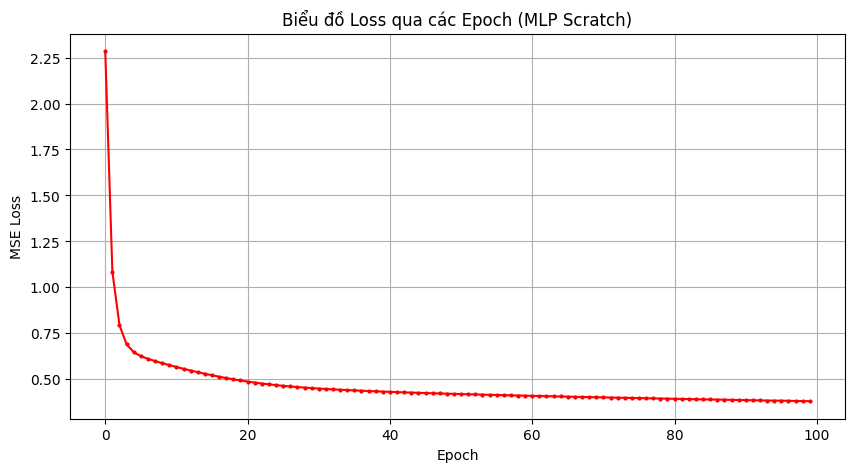

MSE Scratch: 0.3944


In [ ]:
# 4. Đánh giá
plt.figure(figsize=(10, 5))
plt.plot(history_scratch, color='red', marker='o', markersize=2)
plt.title('Biểu đồ Loss qua các Epoch (MLP Scratch)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()

y_pred = mlp.forward(X_test_scaled)
mse = np.mean((y_test - y_pred)**2)
print(f"MSE Scratch: {mse:.4f}")


BẢNG SO SÁNH CÁC MÔ HÌNH:


,Model,MSE,R2 Score
0,MLP (Scratch),0.394373,0.699046
1,Linear Regression,0.555892,0.575788
2,Random Forest,0.255170,0.805275


/tmp/ipykernel_4950/1279988289.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=results, palette='viridis')


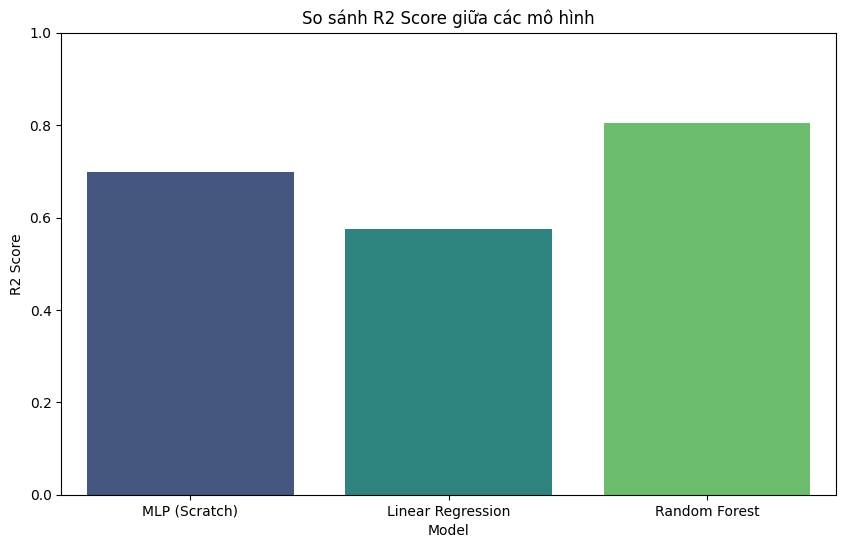

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 5. So sánh với Linear Regression và Random Forest

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train.ravel())
y_pred_lr = lr.predict(X_test_scaled)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train.ravel())
y_pred_rf = rf.predict(X_test_scaled)

# Dự đoán từ MLP Scratch
y_pred_scratch = mlp.forward(X_test_scaled).flatten()

# Tổng hợp kết quả
results = pd.DataFrame({
    'Model': ['MLP (Scratch)', 'Linear Regression', 'Random Forest'],
    'MSE': [
        mean_squared_error(y_test, y_pred_scratch),
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_rf)
    ],
    'R2 Score': [
        r2_score(y_test, y_pred_scratch),
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ]
})

print("\nBẢNG SO SÁNH CÁC MÔ HÌNH:")
display(results)

# Trực quan hóa so sánh
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2 Score', data=results, palette='viridis')
plt.title('So sánh R2 Score giữa các mô hình')
plt.ylim(0, 1)
plt.show()

In [ ]:
# 6. Lưu Model
model_path = 'california_housing_mlp.keras'
mlp_model.save(model_path)
print(f"\nMô hình đã được lưu tại: {model_path}")

# Cách tải lại model:
# from tensorflow.keras.models import load_model
# reloaded_model = load_model(model_path)


Mô hình đã được lưu tại: california_housing_mlp.keras
